<a href="https://colab.research.google.com/github/mohiuddinshahrukh/PM_STEDE_25-26/blob/main/ASPECT_DATA__SET_ARG_MIN_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Cell 1: Install & Setup
import os

# 1. Install Libraries
!pip install amrlib spacy transformers torch pandas --quiet
!python -m spacy download en_core_web_sm --quiet

# 2. Download the AMR Parsing Model (T5-based)
# We manually download it because it's not included in the pip install
model_url = "https://github.com/bjascob/amrlib-models/releases/download/model_parse_t5-v0_2_0/model_parse_t5-v0_2_0.tar.gz"
model_tar = "model_parse_t5-v0_2_0.tar.gz"
model_dir = "model_parse_t5-v0_2_0"

if not os.path.isdir(model_dir):
    print("⬇️ Downloading AMR Model (approx 800MB)...")
    !wget -q {model_url}
    print("📦 Extracting Model...")
    !tar -xzf {model_tar}
    print("✅ Model Ready!")
else:
    print("✅ Model already downloaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 147.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
⬇️ Downloading AMR Model (approx 800MB)...
📦 Extracting Model...
✅ Model Ready!


In [2]:
!pip install unidecode


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.9 MB/s eta 0:00:00


In [4]:
# Cell 2: Run AMR Parsing
import amrlib
import pandas as pd
import torch

# 1. Load the Model we just downloaded
# We point 'model_dir' to the folder we extracted in Step 1
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Loading model on {device}...")

stog = amrlib.load_stog_model(model_dir='model_parse_t5-v0_2_0', device=device)

# 2. Create Sample Data (Since the official CSV is restricted)
# These are real examples similar to the UKP dataset
data = {
    'sentence1': [
        "Fracking can contaminate water and water wells.",
        "The death penalty is a legal punishment.",
        "School uniforms reduce peer pressure."
    ],
    'sentence2': [
        "Hydraulic fracturing poses risks to groundwater quality.",
        "Capital punishment should be abolished.",
        "Uniforms take away student individuality."
    ],
    'topic': ["Fracking", "Death Penalty", "School Uniforms"]
}
# --- THE FIX ---
# Instead of converting to CSV and reading it back, just make the DataFrame directly:
df = pd.DataFrame(data)

# 3. Parse the Arguments
print(f"\nParsing {len(df)} argument pairs...\n")

# We zip the two columns to parse them together
args1 = df['sentence1'].tolist()
args2 = df['sentence2'].tolist()

# Parse all sentences at once
graphs1 = stog.parse_sents(args1)
graphs2 = stog.parse_sents(args2)

# 4. Display Results
for i in range(len(df)):
    print(f"Topic: {df['topic'][i]}")
    print(f"Argument 1: {args1[i]}")
    print(f"AMR Graph 1:\n{graphs1[i]}")
    print("-" * 20)
    print(f"Argument 2: {args2[i]}")
    print(f"AMR Graph 2:\n{graphs2[i]}")
    print("=" * 50 + "\n")

🚀 Loading model on cuda...

Parsing 3 argument pairs...

Topic: Fracking
Argument 1: Fracking can contaminate water and water wells.
AMR Graph 1:
# ::snt Fracking can contaminate water and water wells.
(p / possible-01
      :ARG1 (c / contaminate-01
            :ARG0 (f / fracking)
            :ARG1 (a / and
                  :op1 (w / water)
                  :op2 (w2 / well
                        :mod w))))
--------------------
Argument 2: Hydraulic fracturing poses risks to groundwater quality.
AMR Graph 2:
# ::snt Hydraulic fracturing poses risks to groundwater quality.
(p / pose-02
      :ARG0 (f / fracture-01
            :mod (h / hydraulic))
      :ARG1 (r / risk-01
            :ARG2 (q / quality
                  :mod (g / groundwater))))

Topic: Death Penalty
Argument 1: The death penalty is a legal punishment.
AMR Graph 1:
# ::snt The death penalty is a legal punishment.
(p / punish-01
      :ARG2 (d / die-01)
      :ARG1-of (l / legal-02))
--------------------
Argument 2: 

In [5]:
# Cell 3: Calculate Similarity (Smatch & Concept Overlap)

# 1. Install smatch (Standard AMR metric library)
!pip install smatch --quiet
import smatch
import re

def get_concepts(amr_string):
    """
    Extracts concepts (e.g., 'contaminate-01', 'fracking') from the graph.
    This mimics the 'Concept-focused' metric from Opitz et al..
    """
    # Regex to find (variable / concept) patterns
    # We grab the 'concept' part
    concepts = re.findall(r'\/ ([a-zA-Z0-9\-]+)', amr_string)
    return set(concepts)

def calculate_similarity(graph1, graph2):
    # 1. Structural Similarity (Smatch)
    # get_amr_match returns (f-score, precision, recall)
    # We pass the generator of the single graph
    structural_score = next(smatch.score_amr_pairs([graph1], [graph2]))[2] # Index 2 is F-score

    # 2. Concept Similarity (Jaccard Index)
    # A simple approximation of the paper's 'Concept-Focus' metric
    c1 = get_concepts(graph1)
    c2 = get_concepts(graph2)

    if not c1 or not c2: return 0.0, 0.0, c1, c2

    intersection = c1.intersection(c2)
    union = c1.union(c2)
    concept_score = len(intersection) / len(union)

    return structural_score, concept_score, intersection, c1, c2

# --- Run Analysis on your Data ---
print(f"{'Topic':<15} | {'Struct. Score':<12} | {'Concept Score':<12} | {'Shared Concepts'}")
print("-" * 80)

for i in range(len(df)):
    g1 = graphs1[i]
    g2 = graphs2[i]
    topic = df['topic'][i]

    s_score, c_score, shared, c1, c2 = calculate_similarity(g1, g2)

    # Formatting for display
    shared_str = ", ".join(list(shared)) if shared else "None"

    print(f"{topic:<15} | {s_score:.3f}        | {c_score:.3f}        | {shared_str}")

Topic           | Struct. Score | Concept Score | Shared Concepts
--------------------------------------------------------------------------------
Fracking        | 0.000        | 0.000        | None
Death Penalty   | 0.000        | 0.167        | punish-01
School Uniforms | 0.000        | 0.111        | uniform


Now we try to change the roots and see if the meaning changes and we get new  / modified graphs


In [7]:
# Cell 4: Download Correct Models
import os

# 1. Install Penman (needed for graph manipulation)
!pip install penman --quiet

# --- Download Generator (Graph -> Text) ---
# We use the 'wtense' version from your list
gen_name = "model_generate_t5wtense-v0_1_0"
gen_url = f"https://github.com/bjascob/amrlib-models/releases/download/{gen_name}/{gen_name}.tar.gz"

if not os.path.isdir(gen_name):
    print(f"⬇️ Downloading Generator: {gen_name}...")
    !wget -q {gen_url}
    print("📦 Extracting...")
    !tar -xzf {gen_name}.tar.gz
    print("✅ Generator Ready!")
else:
    print("✅ Generator already downloaded.")

# --- Download Parser (Text -> Graph) ---
# We use the T5 parser from your list (if not already there)
parse_name = "model_parse_t5-v0_2_0"
parse_url = f"https://github.com/bjascob/amrlib-models/releases/download/{parse_name}/{parse_name}.tar.gz"

if not os.path.isdir(parse_name):
    print(f"⬇️ Downloading Parser: {parse_name}...")
    !wget -q {parse_url}
    print("📦 Extracting...")
    !tar -xzf {parse_name}.tar.gz
    print("✅ Parser Ready!")
else:
    print("✅ Parser already downloaded.")

⬇️ Downloading Generator: model_generate_t5wtense-v0_1_0...
📦 Extracting...
✅ Generator Ready!
✅ Parser already downloaded.


In [15]:
import penman
import amrlib
import torch

# 1. Ensure dependencies are present
try:
    import word2number
except ImportError:
    !pip install word2number --quiet

# 2. Corrected Function
def reroot_and_paraphrase(text, stog_model, gtos_model):
    print(f"Original:    {text}")

    # --- Parse (Text -> Graph) ---
    graphs = stog_model.parse_sents([text])
    g = penman.decode(graphs[0])

    old_root = g.top

    # --- Find New Root (ARG1 or ARG0) ---
    new_root = None
    target_triple = None

    # We look through *triples* now, not just edges to keep definitions
    for triple in g.triples:
        source, role, target = triple
        # We look for a link starting from the old root
        if source == old_root:
            if ":ARG1" in role:
                new_root = target
                target_triple = triple
                break

    # Fallback to ARG0 if no ARG1 found
    if not new_root:
        for triple in g.triples:
            source, role, target = triple
            if source == old_root and ":ARG0" in role:
                new_root = target
                target_triple = triple
                break

    if not new_root:
        print("⚠️ Structure too complex to simple-flip (No direct ARG0/ARG1 found).")
        print("-" * 50)
        return

    # --- Construct New Graph ---
    new_triples = []

    # 1. Invert the target link (NewRoot -> ARG-of -> OldRoot)
    inv_role = target_triple[1] + "-of"
    new_triples.append((new_root, inv_role, old_root))

    # 2. Copy EVERYTHING else (Edges AND Instances)
    for triple in g.triples:
        if triple != target_triple:
            new_triples.append(triple)

    # 3. Build Graph
    try:
        g_new = penman.Graph(new_triples, top=new_root)
        new_amr = penman.encode(g_new)
    except Exception as e:
        print(f"Graph Build Error: {e}")
        return

    # --- Generate (Graph -> Text) ---
    try:
        # FIX: Removed 'device=' argument. The model remembers its device.
        paraphrase = gtos_model.generate(graphs=[new_amr])[0]
        print(f"Paraphrased: {paraphrase}")
    except Exception as e:
        print(f"Generation Error: {e}")

    print("-" * 50)

# --- Run the Experiment ---
# Re-load models if variables were lost, or just run with existing 'stog'/'gtos'
if 'stog' not in locals() or 'gtos' not in locals():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Reloading models on {device}...")
    stog = amrlib.load_stog_model(model_dir='model_parse_t5-v0_2_0', device=device)
    gtos = amrlib.load_gtos_model(model_dir='model_generate_t5wtense-v0_1_0', device=device)

arguments = [
    "Active participation in sports improves mental health.",
    "High taxes discourage business investment.",
    "The government should ban plastic bags.",
    "Social media causes anxiety in teenagers."
]

for arg in arguments:
    reroot_and_paraphrase(arg, stog, gtos)

Original:    Active participation in sports improves mental health.
Paraphrased: ['Mind health is improved by active sport participation.']
--------------------------------------------------
Original:    High taxes discourage business investment.
Paraphrased: ['High taxes discourage business investment.']
--------------------------------------------------
Original:    The government should ban plastic bags.
Paraphrased: ['The government should ban plastic bags.']
--------------------------------------------------
Original:    Social media causes anxiety in teenagers.
Paraphrased: ['Teenagers have anxiety over social media.']
--------------------------------------------------


In [17]:
# Cell 5: Fix LayoutError by using g.triples
import penman
import amrlib
import torch

# 1. Install word2number if missing
try:
    import word2number
except ImportError:
    !pip install word2number --quiet

# 2. Load Models (if not already loaded)
if 'stog' not in locals():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"🚀 Reloading models on {device}...")
    stog = amrlib.load_stog_model(model_dir='model_parse_t5-v0_2_0', device=device)
    gtos = amrlib.load_gtos_model(model_dir='model_generate_t5wtense-v0_1_0', device=device)

# 3. Corrected Function
def reroot_and_paraphrase(text):
    print(f"Original:    {text}")

    # --- Parse (Text -> Graph) ---
    graphs = stog.parse_sents([text])
    g = penman.decode(graphs[0])
    old_root = g.top

    # --- Find the target edge in TRIPLES (not just edges) ---
    # We need to find the specific triple that connects root -> ARG1 -> child
    target_triple = None
    new_root = None

    # Check all triples to find the ARG1 connection
    for triple in g.triples:
        source, role, target = triple
        if source == old_root and ":ARG1" in role:
            new_root = target
            target_triple = triple
            break

    # Fallback: Try ARG0 if ARG1 is missing
    if not new_root:
        for triple in g.triples:
            source, role, target = triple
            if source == old_root and ":ARG0" in role:
                new_root = target
                target_triple = triple
                break

    if not new_root:
        print("⚠️ No suitable ARG0/ARG1 found to flip. Skipping.")
        print("-" * 50)
        return

    # --- Build New Triples List ---
    new_triples = []

    # 1. Create the INVERTED connection (NewRoot -> ARG-of -> OldRoot)
    # We take the role from the target_triple (e.g., :ARG1) and add "-of"
    inv_role = target_triple[1] + "-of"
    new_triples.append((new_root, inv_role, old_root))

    # 2. Copy EVERYTHING else (Edges AND Definitions)
    # This is the critical fix: we copy from g.triples, excluding only the one we inverted
    for triple in g.triples:
        if triple != target_triple:
            new_triples.append(triple)

    # --- Generate ---
    try:
        # Create new graph with new root
        g_new = penman.Graph(new_triples, top=new_root)
        new_amr = penman.encode(g_new)

        # Generate text
        paraphrase = gtos.generate(graphs=[new_amr])[0]
        print(f"Paraphrased: {paraphrase}")
    except Exception as e:
        print(f"Error during generation: {e}")

    print("-" * 50)

# 4. Run the Test
arguments = [
    "Active participation in sports improves mental health.",
    "High taxes discourage business investment.",
    "Social media causes anxiety in teenagers."
]

for arg in arguments:
    reroot_and_paraphrase(arg)

Original:    Active participation in sports improves mental health.
Paraphrased: ['Mind health is improved by active sport participation.']
--------------------------------------------------
Original:    High taxes discourage business investment.
Paraphrased: ['High taxes discourage business investment.']
--------------------------------------------------
Original:    Social media causes anxiety in teenagers.
Paraphrased: ['Teenagers have anxiety over social media.']
--------------------------------------------------


Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
Original Sentence: High taxes discourage business investment.

--- 1. Original Structure (Active Voice) ---


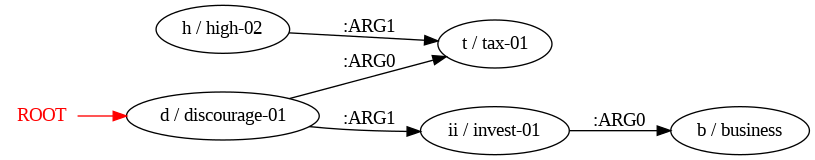


--- 2. Modified Structure (Passive/Flipped) ---


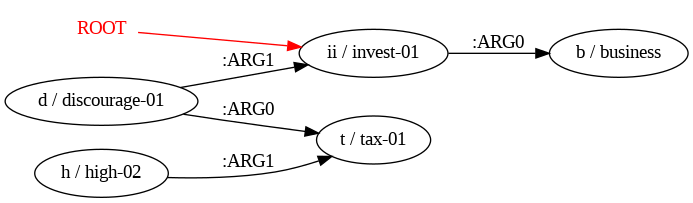

In [18]:
# Cell 6: Visualize the "Explainable" Structural Change
import graphviz
from IPython.display import display, Image

# Install graphviz system dependency (Colab specific)
!apt-get install graphviz --quiet

def draw_amr_graph(penman_string, title="AMR Graph"):
    """
    Converts a Penman string into a visible PNG image using Graphviz.
    """
    g = penman.decode(penman_string)

    # Create a directed graph
    dot = graphviz.Digraph(comment=title, format='png')
    dot.attr(rankdir='LR') # Left-to-Right layout

    # Add Nodes (Instances)
    for source, role, target in g.instances():
        label = f"{source} / {target}" # e.g. "a / active"
        dot.node(source, label)

    # Add Edges (Relations)
    for source, role, target in g.edges():
        dot.edge(source, target, label=role)

    # Add root indication
    dot.node("ROOT", "ROOT", shape="plaintext", fontcolor="red")
    dot.edge("ROOT", g.top, color="red")

    return dot.pipe()

def visualize_reroot(text, stog_model):
    print(f"Original Sentence: {text}")

    # 1. Parse Original
    graphs = stog_model.parse_sents([text])
    original_amr = graphs[0]

    # 2. Manipulate (Re-root logic)
    g = penman.decode(original_amr)
    old_root = g.top

    # Find ARG1 to flip
    new_root = None
    target_triple = None
    for triple in g.triples:
        src, role, tgt = triple
        if src == old_root and ":ARG1" in role:
            new_root = tgt
            target_triple = triple
            break

    if not new_root:
        print("⚠️ Skipped visualization (No ARG1 to flip).")
        return

    # Build New Triples
    new_triples = []
    inv_role = target_triple[1] + "-of"
    new_triples.append((new_root, inv_role, old_root))

    for triple in g.triples:
        if triple != target_triple:
            new_triples.append(triple)

    g_new = penman.Graph(new_triples, top=new_root)
    modified_amr = penman.encode(g_new)

    # 3. Display Both
    print("\n--- 1. Original Structure (Active Voice) ---")
    display(Image(draw_amr_graph(original_amr)))

    print("\n--- 2. Modified Structure (Passive/Flipped) ---")
    display(Image(draw_amr_graph(modified_amr)))
    print("="*60 + "\n")

# Run Visualization
if 'stog' in locals():
    visualize_reroot("High taxes discourage business investment.", stog)

In [19]:
# Cell 7: Hypothesis II - Argument + Conclusion Similarity
from transformers import pipeline
import pandas as pd

# 1. Load a Conclusion Generator (We use a Summarizer as a proxy)
print("🚀 Loading Conclusion Generator (T5)...")
# 't5-small' is fast; assumes "summarize: " input format
conclusion_gen = pipeline("summarization", model="t5-small", device=0 if torch.cuda.is_available() else -1)

def get_conclusion(text):
    # We prompt the model to "summarize" which acts like a conclusion here
    input_text = "summarize: " + text
    res = conclusion_gen(input_text, max_length=20, min_length=5, do_sample=False)
    return res[0]['summary_text']

# 2. Test Data (From your earlier dataframe)
# We will use the first pair from your dataframe 'df'
arg_a = df['sentence1'].iloc[0] # "Fracking can contaminate water..."
arg_b = df['sentence2'].iloc[0] # "Hydraulic fracturing poses risks..."

print(f"Arg A: {arg_a}")
print(f"Arg B: {arg_b}\n")

# 3. Generate Conclusions
conc_a = get_conclusion(arg_a)
conc_b = get_conclusion(arg_b)

print(f"Conclusion A: {conc_a}")
print(f"Conclusion B: {conc_b}\n")

# 4. Parse Conclusions into AMR
print("...Parsing Conclusions into AMR...")
# Ensure 'stog' model is loaded from previous cells
graphs_conc = stog.parse_sents([conc_a, conc_b])

# 5. Measure Similarity (Using your 'calculate_similarity' function)
# We compare Conclusion A vs Conclusion B
s_score, c_score, shared, _, _ = calculate_similarity(graphs_conc[0], graphs_conc[1])

print("-" * 40)
print(f"Conclusion Structural Similarity: {s_score:.3f}")
print(f"Conclusion Concept Similarity:    {c_score:.3f}")
print(f"Shared Concepts: {shared}")
print("-" * 40)

# According to the paper, you combine this with the argument similarity
# Total Score = alpha * Sim(Arguments) + (1-alpha) * Sim(Conclusions)

🚀 Loading Conclusion Generator (T5)...


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cuda:0
Your max_length is set to 20, but your input_length is only 17. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=8)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Arg A: Fracking can contaminate water and water wells.
Arg B: Hydraulic fracturing poses risks to groundwater quality.



Your max_length is set to 20, but your input_length is only 19. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=9)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Conclusion A: Fracking can contaminate water and water wells .
Conclusion B: hydraulic fracturing poses risks to groundwater quality .

...Parsing Conclusions into AMR...
----------------------------------------
Conclusion Structural Similarity: 0.000
Conclusion Concept Similarity:    0.000
Shared Concepts: set()
----------------------------------------
